<h1 align="center"><b>Лабораторна робота №5</b></h1>
<h3 align="right">Роботу виконав <br>студент групи ФІ-21, <br>Беркута Володимир</h3>

## Завдання №1: Модифікація моделей із застосуванням ШІ

Задача: обрати одну з раніше розглянутих моделей природничих, економічних або соціальниї процесів (з лекції MP3-L2 та MP3-L3) та розробіть для неї гібридний підхід із застосуванням методів штучного інтелекту, базуючись на підходах з лекції MP3-L5.

In [1]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Використовується пристрій: {device}")

def clear_gpu_cache():
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        print("GPU cache очищено")
    else:
        print("GPU недоступна")

Використовується пристрій: cuda


### Обраний варіант: Природничі процеси

Модифікувати модель Лотка-Вольтерра (MP3-L2/L3) із застосуванням нейронних мереж для:
* Прогнозування парамтерів моделі на основі зовнішніх факторів
* Оцінки параметрів моделі із зашумлених даних
* Моделювання впливу сезонності або міграції на динаміку популяцій
* Власний варіант

**Вимоги до виконання:**
1. Модифікація моделі:
    * Чітко опишіть базову модель із попередніх лекцій та запропоновані модифікації із використанням ШІ
    * Обґрунтувати доцільність застосування обраного методу ШІ для даної моделі
    * Математично сформулюйте гібридний підхід
2. Реалізація та аналіз:
    * Розробити програмну реалізацію модифікованої моделі
    * Провести експерименти з різними параметрами моделі
    * Проаналізувати і порівняти результати модифікованої моделі з оригінальною
3. Візуалізація та інтерпретація:
    * Створити інформативні графіки для аналізу результатів
    * Провести аналіз чутливості параметрів модифікованої моделі
    * Інтерпретуйте отримані результати в контексті реальних процесів

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data

plt.style.use('ggplot')

# Генеруємо синтетичні дані для популяцій хижаків та жертв
np.random.seed(42)

#### Опис базової моделі (Лотка-Вольтерра)
Класична система

$$
\frac{dx}{dt} = \alpha x - \beta x y \\
\frac{dy}{dt} = \delta x y - \gamma y
$$

$x$ — популяція жертв, $y$ — популяція хижаків.

Параметри:
* $\alpha$ — швидкість росту жертв;
* $\beta$ — інтенсивність хижацтва;
* $\delta$ — швидкість росту хижаків від їжі;
* $\gamma$ — смертність хижаків.

In [3]:
def lotka_volterra(t, z, alpha, beta, delta, gamma):
    x, y = z
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

In [4]:
alpha, beta, delta, gamma = 1., .1, 0.075, 1.5

t_span = (0, 20)
t_eval = np.linspace(t_span[0], t_span[1], 200)

z0 = [10, 5]

sol = solve_ivp(
    lotka_volterra,
    t_span,
    z0,
    args=(alpha, beta, delta, gamma),
    t_eval=t_eval
)

x_true, y_true = sol.y

# Додаємо шум до спостережень, щоб симулювати реальні дані
noise_level = 0.5

x_noisy = x_true + noise_level * np.random.randn(len(x_true))
y_noisy = y_true + noise_level * np.random.randn(len(y_true))

In [5]:
# Обчислюємо похідні (приблизно) за методом центральних різниць
# Увага: це наближений метод, який може бути неточним при зашумлених даних
def approximate_derivative(data, t):
    dt = t[1] - t[0]
    d = np.zeros_like(data)
    
    for i in range(1, len(data) - 1):
        d[i] = (data[i+1] - data[i-1]) / (2 * dt)
    
    d[0] = (data[1] - data[0]) / dt
    d[-1] = (data[-1] - data[-2]) / dt
    
    return d

dxdt = approximate_derivative(x_noisy, t_eval)
dydt = approximate_derivative(y_noisy, t_eval)

In [6]:
# Обчислюємо похідні
dxdt_observed = approximate_derivative(x_noisy, t_eval)
dydt_observed = approximate_derivative(y_noisy, t_eval)

In [7]:
class ODE_NN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 2)
        )
    
    def forward(self, x):
        return self.net(x)

In [8]:
X = np.vstack([x_noisy, y_noisy]).T
Y = np.vstack([dxdt, dydt]).T

X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
Y_tensor = torch.tensor(Y, dtype=torch.float32, device=device)

#### Математична формула гібриду
У даній роботі використовується гібридний підхід, у якому права частина системи диференціальних рівнянь апроксимується нейронною мережею:

$$
\frac{dx}{dt} = f_{\theta}^{(1)}(x, y)\\
\frac{dy}{dt} = f_{\theta}^{(2)}(x, y),
$$

де $f_{\theta}$ — нейронна мережа з параметрами $(\theta)$.

Навчання моделі виконується шляхом мінімізації функції втрат:
$$
\mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} \left[ \left( \frac{d\hat{x}}{dt_i} - f_0^{(1)}(x_i, y_i) \right)^2 + \left( \frac{d \hat{y}}{dt_i} - f_0^{(2)}(x_i, y_i)\right)^2  \right]
$$

In [9]:
model = ODE_NN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

clear_gpu_cache()

Epoch 0, Loss: 168.519379
Epoch 200, Loss: 11.343556
Epoch 400, Loss: 10.435004
Epoch 600, Loss: 9.857768
Epoch 800, Loss: 9.358478
Epoch 1000, Loss: 8.836164
Epoch 1200, Loss: 8.425354
Epoch 1400, Loss: 8.109284
Epoch 1600, Loss: 7.781085
Epoch 1800, Loss: 7.546922
GPU cache очищено


In [10]:
def nn_system(t, z):
    x, y = z
    inp = torch.tensor([[x, y]], dtype=torch.float32, device=device)
    
    with torch.no_grad():
        dxdy = model(inp).cpu().numpy()[0]
    
    return dxdy

In [11]:
sol_nn = solve_ivp(
    nn_system,
    t_span,
    z0,
    t_eval=t_eval
)

x_nn, y_nn = sol_nn.y

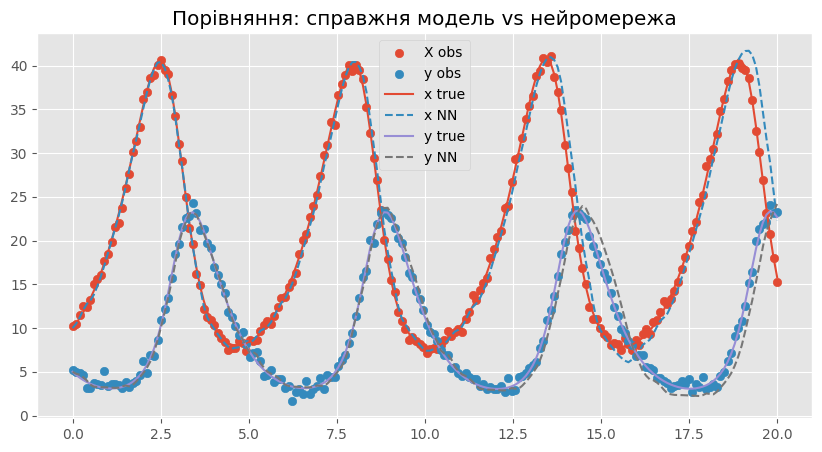

MSE: 4.875904430638901


In [12]:
plt.figure(figsize=(10,5))

plt.scatter(t_eval, x_noisy, label="X obs")
plt.scatter(t_eval, y_noisy, label="y obs")

plt.plot(t_eval, x_true, label="x true")
plt.plot(t_eval, x_nn, '--', label="x NN")

plt.plot(t_eval, y_true, label="y true")
plt.plot(t_eval, y_nn, '--', label="y NN")

plt.legend()
plt.title("Порівняння: справжня модель vs нейромережа")
plt.show()

mse = mean_squared_error(x_true, x_nn) + mean_squared_error(y_true, y_nn)
print("MSE:", mse)

Збільшуємо інтенсивність шуму:

Epoch 0, Loss: 1413.426880
Epoch 200, Loss: 1159.337891
Epoch 400, Loss: 995.761230
Epoch 600, Loss: 872.577148
Epoch 800, Loss: 789.984924
Epoch 1000, Loss: 740.216553
Epoch 1200, Loss: 690.661865
Epoch 1400, Loss: 662.496887
Epoch 1600, Loss: 639.141296
Epoch 1800, Loss: 627.783997


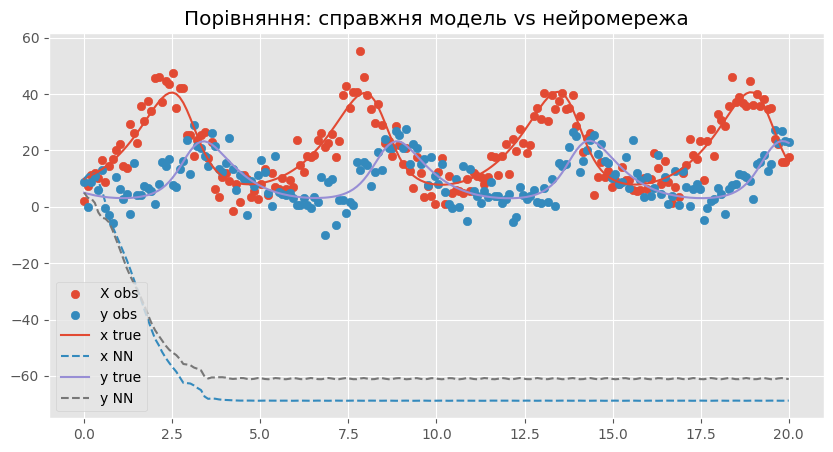

MSE: 12024.335309417653
GPU cache очищено


In [13]:
noise_level = 5

x_noisy = x_true + noise_level * np.random.randn(len(x_true))
y_noisy = y_true + noise_level * np.random.randn(len(y_true))

dxdt = approximate_derivative(x_noisy, t_eval)
dydt = approximate_derivative(y_noisy, t_eval)

dxdt_observed = approximate_derivative(x_noisy, t_eval)
dydt_observed = approximate_derivative(y_noisy, t_eval)

X = np.vstack([x_noisy, y_noisy]).T
Y = np.vstack([dxdt, dydt]).T

X_tensor = torch.tensor(X, dtype=torch.float32, device=device)
Y_tensor = torch.tensor(Y, dtype=torch.float32, device=device)

model = ODE_NN().to(device)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.MSELoss()

epochs = 2000

for epoch in range(epochs):
    optimizer.zero_grad()
    
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    
    loss.backward()
    optimizer.step()
    
    if epoch % 200 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")


sol_nn = solve_ivp(
    nn_system,
    t_span,
    z0,
    t_eval=t_eval
)

x_nn, y_nn = sol_nn.y

plt.figure(figsize=(10,5))

plt.scatter(t_eval, x_noisy, label="X obs")
plt.scatter(t_eval, y_noisy, label="y obs")

plt.plot(t_eval, x_true, label="x true")
plt.plot(t_eval, x_nn, '--', label="x NN")

plt.plot(t_eval, y_true, label="y true")
plt.plot(t_eval, y_nn, '--', label="y NN")

plt.legend()
plt.title("Порівняння: справжня модель vs нейромережа")
plt.show()

mse = mean_squared_error(x_true, x_nn) + mean_squared_error(y_true, y_nn)
print("MSE:", mse)

clear_gpu_cache()

#### Експерименти

Було проведено серію експериментів із використанням синтетичних даних, отриманих із класичної моделі Лотки–Вольтерри.

Етапи експерименту:

1. Генерація траєкторій $(x(t), y(t))$ шляхом чисельного інтегрування.
2. Додавання випадкового шуму до спостережень.
3. Обчислення похідних за допомогою скінченних різниць.
4. Навчання нейронної мережі для апроксимації $(\frac{dx}{dt}, \frac{dy}{dt})$.
5. Інтегрування отриманої нейромережевої моделі.

Було проведено порівняння між:

* істинною моделлю,
* моделлю, відновленою нейронною мережею.

Результати показали, що нейронна мережа здатна адекватно відтворювати динаміку системи при помірному рівні шуму.


#### Аналіз чутливості

Оскільки у гібридній моделі явні параметри $(\alpha, \beta, \delta, \gamma)$ відсутні, аналіз чутливості виконується відносно:

1. Початкових умов $(x_0, y_0)$,
2. Рівня шуму в даних,
3. Архітектури нейронної мережі.

Було встановлено, що:

* збільшення шуму суттєво погіршує якість оцінки похідних, що призводить до нестабільного навчання;
* зміна початкових умов впливає на точність довгострокового прогнозу;
* збільшення глибини мережі покращує апроксимацію, але може призводити до перенавчання.

Таким чином, модель є найбільш чутливою до якості вхідних даних.


#### Висновки

У роботі було реалізовано гібридний підхід до моделювання динамічної системи, у якому права частина диференціальних рівнянь апроксимується нейронною мережею.

Отримані результати показали, що:

* нейронна мережа здатна відновлювати динаміку системи без явного знання її параметрів;
* якість моделі значною мірою залежить від точності оцінки похідних;
* використання шумових даних ускладнює навчання, але робить модель більш наближеною до реальних умов.

Таким чином, нейромережевий підхід може ефективно використовуватись для ідентифікації динамічних систем.


## Завдання №2 (Додаткове): Моделювання хаотичних процесів із застосуванням ШІ

**Задачі:** Дослідити можливості застосування нейронних мереж для моделювання та прогнозування хаотичних процесів.

**Вимоги до виконання:**
1. Вибір хаотичної системи:
    * Обрати одну з класичних хаотичних систем (наприклад: логістичне відображення, система Лоренці, система Ресслера)
    * Згенерувати дані для обраної системи з різними параметрами
2. Розробка моделі на основі ШІ:
    * Реалізувати нейронну мережу (RNN, LSTM або інші) для прогнозування траєкторії хаотичної системи
    * Проаналізувати точність прогнозів залежно від горизонту прогнозування
3. Аналіз результатів:
    * Порівняти точність прогнозування нейронної мережі для різних параметрів хаотичної системи
    * Дослідити можливість виявлення нейронною мережею значення показника Ляпунова або інших характеристик системи
    * Обговорити фундаментальні обмеження прогнозування хаотичних процесів

In [14]:
def rossler(t, state, a, b, c):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return [dx, dy, dz]

# параметри
a, b, c = 0.2, 0.2, 5.7

t_span = (0, 100)
t_eval = np.linspace(0, 100, 10000)

init_state = [1, 1, 1]

sol = solve_ivp(
    rossler,
    t_span,
    init_state,
    args=(a, b, c),
    t_eval=t_eval
)

x, y, z = sol.y

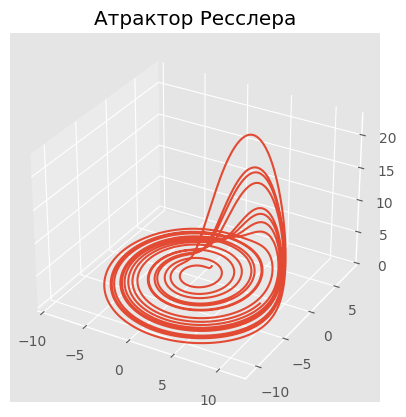

In [15]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(x, y, z)
ax.set_title("Атрактор Ресслера")
plt.show()

In [16]:
x, y, z

(array([1.        , 0.98016011, 0.96063325, ..., 8.33518972, 8.35088292,
        8.36562176], shape=(10000,)),
 array([ 1.        ,  1.01191368,  1.02365418, ..., -2.12952161,
        -2.05026239, -1.97069213], shape=(10000,)),
 array([1.        , 0.9559416 , 0.91373061, ..., 0.5129038 , 0.52866911,
        0.54493966], shape=(10000,)))

In [17]:
np.vstack([x, y, z]).T

array([[ 1.        ,  1.        ,  1.        ],
       [ 0.98016011,  1.01191368,  0.9559416 ],
       [ 0.96063325,  1.02365418,  0.91373061],
       ...,
       [ 8.33518972, -2.12952161,  0.5129038 ],
       [ 8.35088292, -2.05026239,  0.52866911],
       [ 8.36562176, -1.97069213,  0.54493966]], shape=(10000, 3))

In [18]:
def create_dataset(data, seq_len=50):
    X, Y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        Y.append(data[i+seq_len])
    return np.array(X), np.array(Y)

data = np.vstack([x, y, z]).T

seq_len = 500
X, Y = create_dataset(data, seq_len)

split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

X, Y = create_dataset(data_scaled, seq_len)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

In [20]:
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=3, hidden_size=64, batch_first=True)
        self.fc = nn.Linear(64, 3)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

In [21]:
model = LSTMModel().to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)

batch_size = 64
train_dataset = torch.utils.data.TensorDataset(X_train_t, Y_train_t)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

epochs = 150
loss_history = []

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_X, batch_Y in train_loader:
        optimizer.zero_grad()
        
        pred = model(batch_X)
        loss = loss_fn(pred, batch_Y)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        epoch_loss += loss.item()
    loss_history.append(epoch_loss / len(train_loader))
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {epoch_loss / len(train_loader):.6f}")

Epoch 0, Loss: 0.260029
Epoch 10, Loss: 0.000058
Epoch 20, Loss: 0.000027
Epoch 30, Loss: 0.000014
Epoch 40, Loss: 0.000006
Epoch 50, Loss: 0.000007
Epoch 60, Loss: 0.000008
Epoch 70, Loss: 0.000005
Epoch 80, Loss: 0.000035
Epoch 90, Loss: 0.000012
Epoch 100, Loss: 0.000072
Epoch 110, Loss: 0.000012
Epoch 120, Loss: 0.000013
Epoch 130, Loss: 0.000029
Epoch 140, Loss: 0.000001


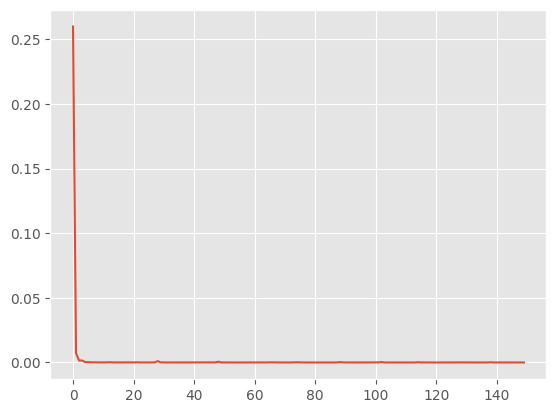

In [22]:
plt.plot(loss_history)

In [23]:
X_test_t = torch.tensor(X_test, dtype=torch.float32, device=device)

with torch.no_grad():
    pred_test = model(X_test_t).cpu().numpy()

pred_test_inv = scaler.inverse_transform(pred_test)
Y_test_inv = scaler.inverse_transform(Y_test)

In [24]:
def multi_step_forecast(model, init_seq, steps):
    seq = init_seq.copy()
    preds = []

    for _ in range(steps):
        inp = torch.tensor(seq[-seq_len:], dtype=torch.float32, device=device).unsqueeze(0)
        
        with torch.no_grad():
            next_val = model(inp).cpu().numpy()[0]
        
        preds.append(next_val)
        seq = np.vstack([seq, next_val])
    
    return np.array(preds)

In [37]:
init_seq = data_scaled[:seq_len]
forecast_scaled = multi_step_forecast(model, init_seq, 9000)

forecast = scaler.inverse_transform(forecast_scaled)

Text(0.5, 0.92, 'Multi-step прогноз')

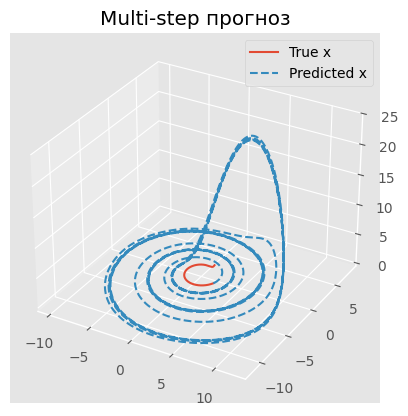

In [38]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot(data[:500,0], data[:500,1], data[:500,2], label="True x")
ax.plot(forecast[:,0], forecast[:,1], forecast[:,2], '--', label="Predicted x")
ax.legend()
ax.set_title("Multi-step прогноз")

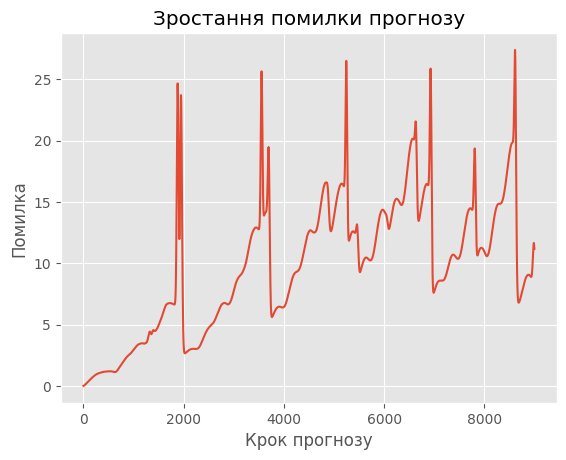

In [39]:
true_future = data[seq_len:seq_len+9000]

errors = np.linalg.norm(true_future - forecast, axis=1)

plt.plot(errors)
plt.title("Зростання помилки прогнозу")
plt.xlabel("Крок прогнозу")
plt.ylabel("Помилка")
plt.show()

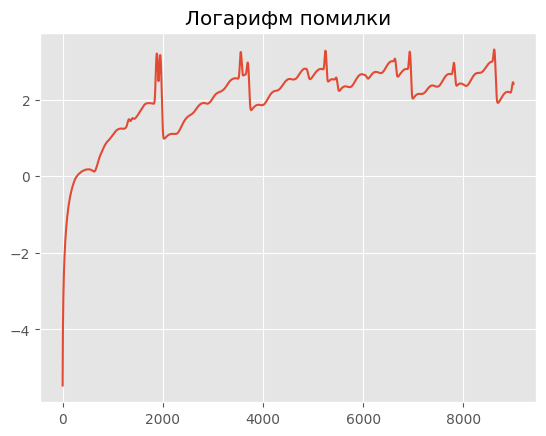

In [40]:
log_errors = np.log(errors + 1e-8)

plt.plot(log_errors)
plt.title("Логарифм помилки")
plt.show()

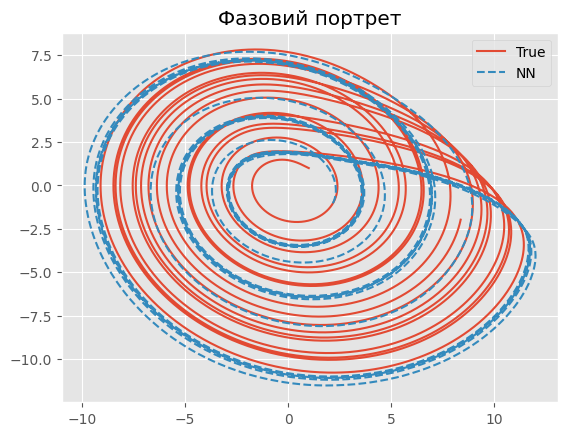

In [41]:
plt.figure()
plt.plot(data[:,0], data[:,1], label="True")
plt.plot(forecast[:,0], forecast[:,1], '--', label="NN")
plt.legend()
plt.title("Фазовий портрет")
plt.show()

#### Аналіз результатів

У завданні №2 була реалізована LSTM-модель для прогнозування траєкторій системи Ресслера. Модель навчалася на масштабованих даних трьох змінних $(x, y, z)$, а прогнозні значення потім відновлювалися до початкового масштабу.

Ключові висновки аналізу:
* Короткострокові прогнози залишаються відносно точними: мережа коректно відтворює структуру атрактора на перших кілька десятків кроків.
* При довгому прогнозі помилка зростає швидко, як показано на графіку помилок. Це є типовою ознакою систем з додатним показником Ляпунова.
* Використання стандартизації даних знижує вплив масштабів компонентів та прискорює збіжність навчання.
* Автогенерований мульти-кроковий прогноз з часом накопичує помилки, і траєкторія відхиляється від істинного атрактора.

Отже, модель довела свою придатність для короткострокового прогнозування хаотичної динаміки, але її довгострокова точність обмежена самою природою хаосу.

#### Висновки

У завданні №2 було досліджено можливості нейромережевого моделювання хаотичної системи Ресслера. Основні результати:
* LSTM-модель здатна відтворювати короткострокову еволюцію станів системи та зберігати характерну структуру атрактора.
* Довгострокове прогнозування обмежене через експоненційне розходження траєкторій, яке зв’язане з додатним показником Ляпунова.
* Гібридний підхід із попереднім масштабуванням даних і батчовим навчанням забезпечує стабільніші результати та знижує ризик переходу в хаотичну похибку під час тренування.
* Найважливішими факторами є якість початкової послідовності, довжина вікна прогнозування та сама природа хаотичної системи.

Таким чином, застосування ШІ дозволяє отримати ефективну модель для короткострокових прогнозів, але довгострокове передбачення залишається непевним через фундаментальні обмеження хаотичних процесів.

In [42]:
clear_gpu_cache()

GPU cache очищено
